<a href="https://colab.research.google.com/github/PaulinaG27/Ciencia-Datos/blob/main/sesiones_practicas%20/sp_4_julian_isaza_marin_paulina_garcia_aristizabal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Julian Isaza Marin -  1001478400

Paulina García Aristizábal - 1000414258

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

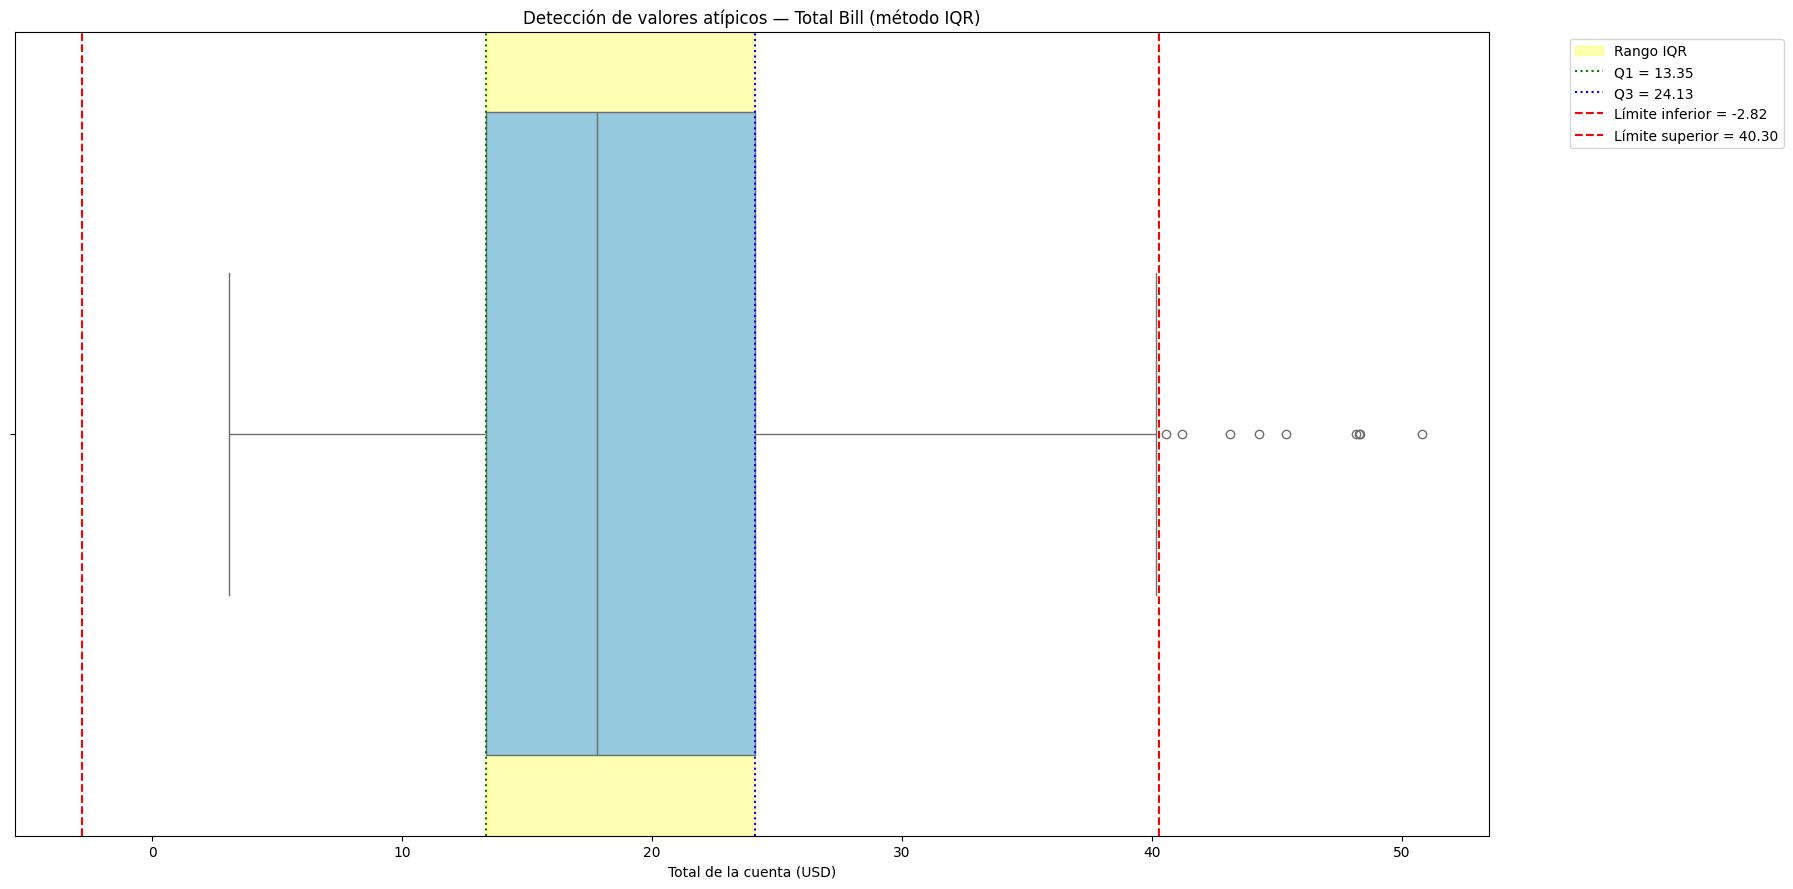

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")

Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
tips['outlier_iqr'] = (tips['total_bill'] < lim_inf) | (tips['total_bill'] > lim_sup)

plt.figure(figsize=(18, 9))
sns.boxplot(x=tips['total_bill'], color='skyblue')
plt.axvspan(Q1, Q3, color='yellow', alpha=0.3, label='Rango IQR')
plt.axvline(Q1,      color='green', linestyle=':',  label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3,      color='blue',  linestyle=':',  label=f'Q3 = {Q3:.2f}')
plt.axvline(lim_inf, color='red',   linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red',   linestyle='--', label=f'Límite superior = {lim_sup:.2f}')

plt.xlabel('Total de la cuenta (USD)')
plt.title('Detección de valores atípicos — Total Bill (método IQR)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Análisis**

La distribución de total_bill se concentra entre \$3 y \$40, con la mayoría de los valores dentro del rango intercuartílico [Q1=13, Q3=24]. Se identifican valores atípicos exclusivamente en el extremo superior. Estos atípicos corresponden a cuentas superiores a \$40, representando mesas con consumos significativamente más altos que el resto. La ausencia de atípicos inferiores sugiere que las cuentas bajas, aunque existen, no se alejan lo suficiente de la mediana como para considerarse inusuales.

# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

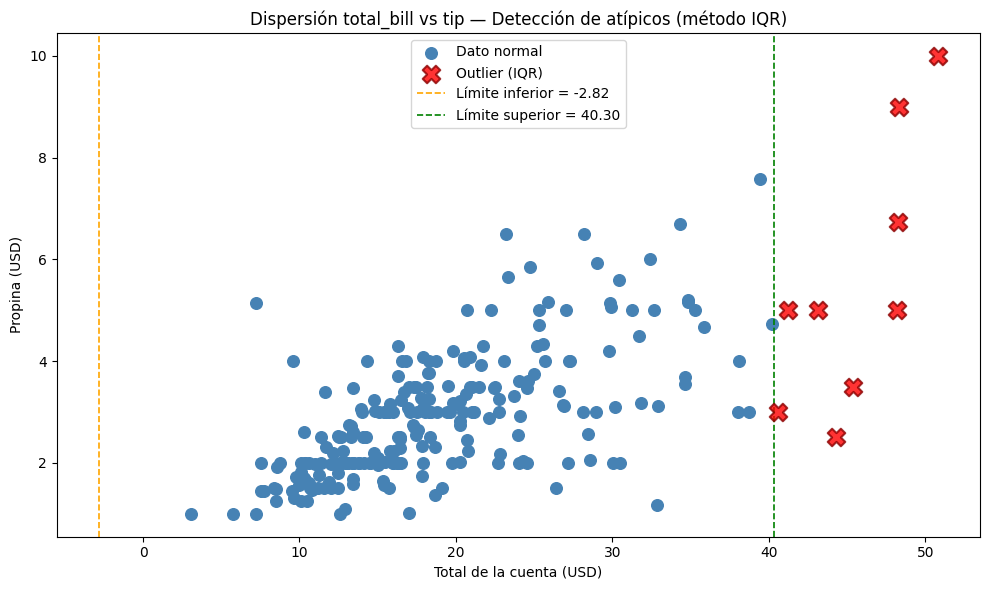

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tips = sns.load_dataset("tips")

# Calcular outliers por IQR para total_bill
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

tips['outlier'] = (tips['total_bill'] < lim_inf) | (tips['total_bill'] > lim_sup)

fig, ax = plt.subplots(figsize=(10, 6))

# Puntos normales
normales = tips[~tips['outlier']]
ax.scatter(normales['total_bill'], normales['tip'],
           color='steelblue', s=70, label='Dato normal', zorder=2)

# Outliers
outliers = tips[tips['outlier']]
ax.scatter(outliers['total_bill'], outliers['tip'],
           color='red', marker='X', s=160, alpha=0.8,
           edgecolors='darkred', linewidths=1.5,
           label='Outlier (IQR)', zorder=3)

# Línites IQR
ax.axvline(lim_inf, linestyle='--', color='orange', linewidth=1.2,
           label=f'Límite inferior = {lim_inf:.2f}')
ax.axvline(lim_sup, linestyle='--', color='green', linewidth=1.2,
           label=f'Límite superior = {lim_sup:.2f}')

ax.set_xlabel('Total de la cuenta (USD)')
ax.set_ylabel('Propina (USD)')
ax.set_title('Dispersión total_bill vs tip — Detección de atípicos (método IQR)')
ax.legend()
plt.tight_layout()
plt.show()


**Análisis**

Los outliers detectados corresponden a cuentas superiores a \$40.30 los cuales representan los montos más altos del dataset, sus propinas varían entre un aproximado de \$2.50 y \$10 lo que indica que las cuentas aunque sean grandes no siempre garantizan unas propinas proporcionales, sin embargo, se evidencia que la propina crece a medida que la cuenta crece. No se consideró el limite inferior ya que -\$2.82 no tiene aplicación práctica o de interpretación ya que las cuentas no pueden ser negativas

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

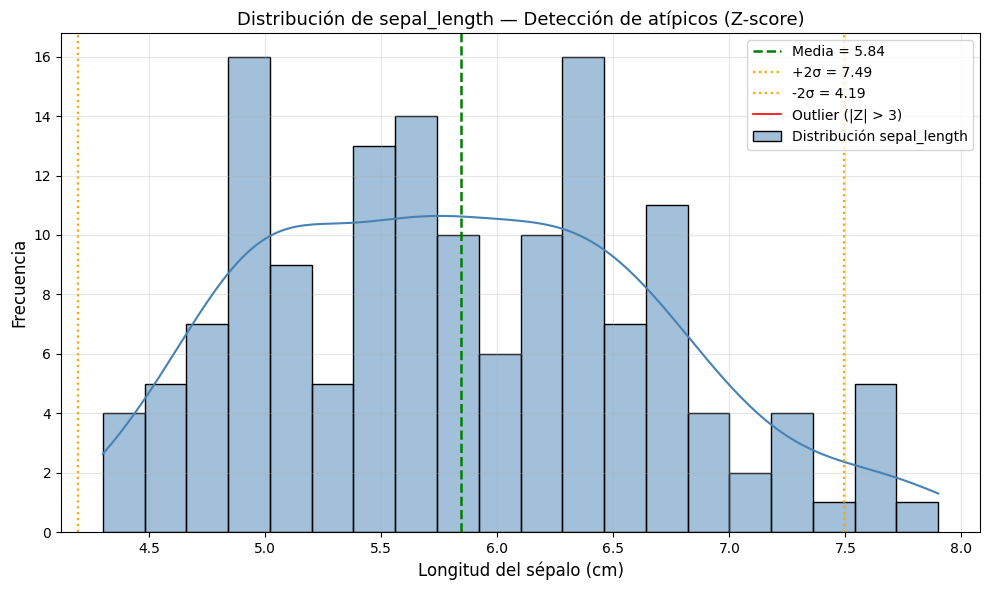


Media: 5.84 | Desv. estándar: 0.83
Outliers detectados (|Z| > 3): 0


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

# Calcular Z-scores y detectar outliers
z_scores = stats.zscore(x)
outliers = x[np.abs(z_scores) > 3]
outliers_z = z_scores[np.abs(z_scores) > 3]

media = np.mean(x)
std = np.std(x)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(x, bins=20, kde=True, color='steelblue', ax=ax,
             label='Distribución sepal_length')

# Línea de la media
ax.axvline(media, color='green', linestyle='--', linewidth=1.8,
           label=f'Media = {media:.2f}')

# Líneas ±2σ
ax.axvline(media + 2*std, color='orange', linestyle=':', linewidth=1.6,
           label=f'+2σ = {media + 2*std:.2f}')
ax.axvline(media - 2*std, color='orange', linestyle=':', linewidth=1.6,
           label=f'-2σ = {media - 2*std:.2f}')

# Marcar outliers con línea roja y etiqueta Z
for out, z in zip(outliers, outliers_z):
    ax.axvline(out, color='red', linestyle='-', linewidth=1.2, alpha=0.7)
    ax.text(out + 0.03, ax.get_ylim()[1] * 0.6,
            f'Z={z:.2f}', rotation=90, color='red', fontsize=9)

# Línea fantasma solo para añadir "Outlier (|Z|>2)" a la leyenda
ax.axvline(np.nan, color='red', linestyle='-', linewidth=1.2,
           label='Outlier (|Z| > 3)')

# Etiquetas y formato
ax.set_xlabel('Longitud del sépalo (cm)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de sepal_length — Detección de atípicos (Z-score)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMedia: {media:.2f} | Desv. estándar: {std:.2f}")
print(f"Outliers detectados (|Z| > 3): {len(outliers)}")
for out, z in zip(outliers, outliers_z):
    print(f"  Valor: {out:.1f} cm  →  Z = {z:.2f}")

**Análisis**

Bajo el criterio estricto de $|Z| > 3$, no se visualizan outliers en la gráfica, lo que indica que no hay errores de medición extremos o valores fuera de toda lógica biológica. Sin embargo, existen registros en el extremo derecho con un $Z \approx 2.49$ (longitudes > 7.7 cm) que, si bien no alcanzan el umbral de 3, se alejan significativamente de la media y podrían considerarse "atípicos leves" bajo un umbral de 2. La distribución muestra una clara multimodalidad, reflejando la mezcla de tres especies con promedios distintos, lo que desplaza la media general a 5.84 cm y hace que los valores más altos de la especie Virginica rocen la zona de exclusión. En conclusión, el outlier "existe" por su distancia visual al grupo principal, pero su clasificación técnica depende totalmente de la sensibilidad del umbral seleccionado.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

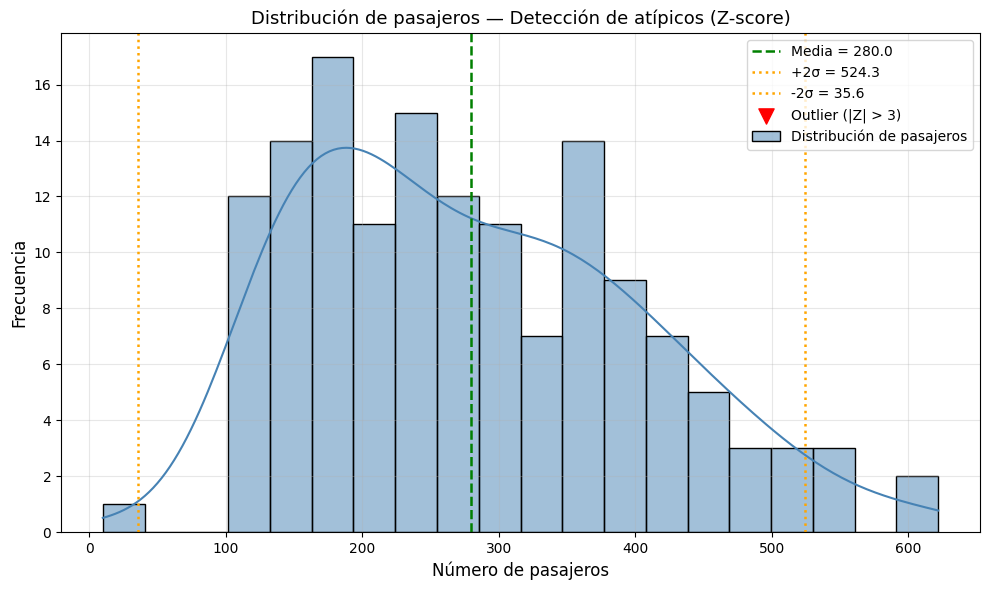


Media: 280.0 | Desv. estándar: 122.2
Outliers detectados (|Z| > 3): 0


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values

# Agregar valores atípicos artificiales
x = np.append(x, [10, 500])

# Calcular Z-scores
z_scores = zscore(x)
outlier_mask = np.abs(z_scores) > 3

media = np.mean(x)
std = np.std(x)
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(x, bins=20, kde= True, color='steelblue', ax=ax,
             label='Distribución de pasajeros')

# Línea de la media
ax.axvline(media, color='green', linestyle='--', linewidth=1.8,
           label=f'Media = {media:.1f}')

# Líneas ±2σ
ax.axvline(media + 2*std, color='orange', linestyle=':', linewidth=1.8,
           label=f'+2σ = {media + 2*std:.1f}')
ax.axvline(media - 2*std, color='orange', linestyle=':', linewidth=1.8,
           label=f'-2σ = {media - 2*std:.1f}')

# Outliers marcados en el eje X
ax.scatter(x[outlier_mask], np.zeros_like(x[outlier_mask]),
           color='red', s=120, marker='v', zorder=5,
           label='Outlier (|Z| > 3)')

# Etiqueta Z-score
for val, z in zip(x[outlier_mask], z_scores[outlier_mask]):
    ax.text(val, 0.5, f'Z={z:.2f}', color='red',
            fontsize=9, ha='center', rotation=90)

# Etiquetas y formato
ax.set_xlabel('Número de pasajeros', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de pasajeros — Detección de atípicos (Z-score)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMedia: {media:.1f} | Desv. estándar: {std:.1f}")
print(f"Outliers detectados (|Z| > 3): {outlier_mask.sum()}")
for val, z in zip(x[outlier_mask], z_scores[outlier_mask]):
    print(f"  Valor: {val}  →  Z = {z:.2f}")

**Análisis**

La distribución del número de pasajeros presenta una forma aproximadamente normal con ligera asimetría hacia la derecha, lo que indica la presencia de algunos valores altos más dispersos. La media se sitúa alrededor de 280 pasajeros, funcionando como centro de la distribución, mientras que la mayoría de los datos se concentra entre ~100 y ~450 pasajeros.

Se añadieron valores extremos (por ejemplo, 10 y 500) con la intención de generar posibles atípicos. Visualmente, el valor cercano a 10 aparece muy alejado del resto de la distribución, especialmente por debajo del límite inferior de -2σ (~36), lo que sugiere un comportamiento atípico claro desde el punto de vista gráfico.

Sin embargo, al aplicar el criterio de detección basado en Z-score con umbral estricto de |Z| > 3, no se identifica ningún outlier. Esto ocurre porque, aunque hay valores alejados, no son lo suficientemente extremos en términos de desviaciones estándar como para superar ese límite. Es decir, el outlier “existe” visualmente y conceptualmente, pero no es clasificado como tal bajo la regla definida.